In [22]:
import config as k
import ccxt
import pandas as pd
import numpy as np
import pandas_ta as ta
import decimal as dc
import matplotlib as mt
import time
from ta.momentum import RSIIndicator

binance = ccxt.binance({
    'enableRateLimit': True,
    'apiKey': k.binancekey,
    'secret': k.binacesecret,
    'options': {
        'defaultType': 'future'
    },
})

symbol = 'ETH/USDT'
timeframe = '1h'
bars = binance.fetch_ohlcv(symbol=symbol, timeframe=timeframe, limit=1000)
df_candles = pd.DataFrame(bars, columns=['time', 'abertura', 'max', 'min', 'fechamento', 'volume'])
df_candles['time'] = pd.to_datetime(df_candles['time'], unit='ms', utc=True).map(lambda x: x.tz_convert('America/Sao_Paulo'))

In [23]:
df_candles['suporte' ] = df_candles['min'].rolling(window=500).min()
df_candles['resistencia'] = df_candles['max'].rolling(window=500).max()


In [24]:
df_candles

,time,abertura,max,min,fechamento,volume,suporte,resistencia
0,2024-12-19 09:00:00-03:00,3703.74,3708.36,3672.68,3678.43,103323.384,NaN,NaN
1,2024-12-19 10:00:00-03:00,3678.44,3698.21,3671.78,3677.18,111972.912,NaN,NaN
2,2024-12-19 11:00:00-03:00,3677.19,3700.00,3633.62,3636.60,303387.189,NaN,NaN
3,2024-12-19 12:00:00-03:00,3636.60,3639.18,3571.12,3612.46,491000.364,NaN,NaN
4,2024-12-19 13:00:00-03:00,3612.46,3635.90,3587.15,3618.90,192387.308,NaN,NaN
...,...,...,...,...,...,...,...,...
995,2025-01-29 20:00:00-03:00,3130.57,3147.31,3108.02,3112.55,73257.091,2900.0,3524.85
996,2025-01-29 21:00:00-03:00,3112.54,3125.84,3089.00,3122.92,101742.840,2900.0,3524.85
997,2025-01-29 22:00:00-03:00,3122.93,3154.43,3119.15,3136.99,107348.174,2900.0,3524.85
998,2025-01-29 23:00:00-03:00,3137.00,3154.27,3126.73,3154.27,72112.735,2900.0,3524.85


In [4]:
smas = [5,10,50,200]

for sma in smas:
    df_candles[f'SMA_{sma}'] = df_candles['fechamento'].rolling(sma).mean()

df_candles['SMA_20'] = ta.sma(close = df_candles.fechamento, length=20)  #biblioteca propria para analise tecnica de dados
df_candles['EMA_20'] = ta.ema(close = df_candles.fechamento, length=20) #EMA da um peso maior para o pesos mais recentes 

In [5]:
df_candles

,time,abertura,max,min,fechamento,volume,SMA_5,SMA_10,SMA_50,SMA_200,SMA_20,EMA_20
0,2025-01-09 05:00:00-03:00,93176.5,93364.4,92700.0,92986.9,18074.938,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-09 06:00:00-03:00,92987.0,93700.0,92926.6,93472.0,5819.112,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-09 07:00:00-03:00,93472.1,93625.9,92975.7,93422.5,5668.622,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-09 08:00:00-03:00,93422.6,93832.8,93167.8,93414.4,5511.471,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-09 09:00:00-03:00,93414.3,93650.0,93109.3,93378.9,4695.010,93334.94,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
495,2025-01-29 20:00:00-03:00,103440.1,104303.0,103414.2,103698.2,4972.025,103705.18,102967.77,102369.088,103545.1160,102671.365,102793.777884
496,2025-01-29 21:00:00-03:00,103698.1,104082.8,103224.5,103978.3,4780.524,103790.74,103166.63,102416.952,103540.2300,102772.455,102906.589514
497,2025-01-29 22:00:00-03:00,103978.3,104533.3,103880.0,104221.9,4883.966,103804.02,103395.40,102460.964,103530.6070,102872.635,103031.857179
498,2025-01-29 23:00:00-03:00,104221.9,104647.5,103944.9,104644.1,5060.964,103996.50,103654.07,102517.596,103519.6575,102966.675,103185.404115


<Axes: >

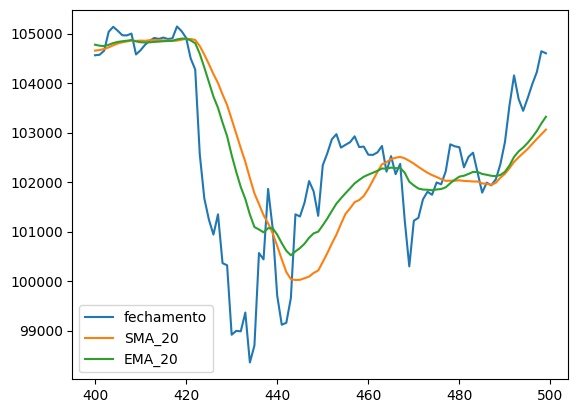

In [6]:
df_candles[['fechamento', 'SMA_20', 'EMA_20']][400:500].plot()

In [7]:
rsi = RSIIndicator(df_candles['fechamento'])
df_candles['RSI'] = rsi.rsi()

In [8]:
df_candles

,time,abertura,max,min,fechamento,volume,SMA_5,SMA_10,SMA_50,SMA_200,SMA_20,EMA_20,RSI
0,2025-01-09 05:00:00-03:00,93176.5,93364.4,92700.0,92986.9,18074.938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-09 06:00:00-03:00,92987.0,93700.0,92926.6,93472.0,5819.112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-09 07:00:00-03:00,93472.1,93625.9,92975.7,93422.5,5668.622,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-09 08:00:00-03:00,93422.6,93832.8,93167.8,93414.4,5511.471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-09 09:00:00-03:00,93414.3,93650.0,93109.3,93378.9,4695.010,93334.94,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2025-01-29 20:00:00-03:00,103440.1,104303.0,103414.2,103698.2,4972.025,103705.18,102967.77,102369.088,103545.1160,102671.365,102793.777884,62.171960
496,2025-01-29 21:00:00-03:00,103698.1,104082.8,103224.5,103978.3,4780.524,103790.74,103166.63,102416.952,103540.2300,102772.455,102906.589514,64.467657
497,2025-01-29 22:00:00-03:00,103978.3,104533.3,103880.0,104221.9,4883.966,103804.02,103395.40,102460.964,103530.6070,102872.635,103031.857179,66.378674
498,2025-01-29 23:00:00-03:00,104221.9,104647.5,103944.9,104644.1,5060.964,103996.50,103654.07,102517.596,103519.6575,102966.675,103185.404115,69.445835


In [9]:
bollinger_bands = ta.bbands(df_candles.fechamento, length= 20 ,  std=2)

In [10]:
bollinger_bands = bollinger_bands.iloc[:,[0,1,2]]
bollinger_bands.columns = ['BBLower', 'BBMedian', 'BBuper']
df_candles = pd.concat([df_candles, bollinger_bands], axis=1)
df_candles

,time,abertura,max,min,fechamento,volume,SMA_5,SMA_10,SMA_50,SMA_200,SMA_20,EMA_20,RSI,BBLower,BBMedian,BBuper
0,2025-01-09 05:00:00-03:00,93176.5,93364.4,92700.0,92986.9,18074.938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-09 06:00:00-03:00,92987.0,93700.0,92926.6,93472.0,5819.112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-09 07:00:00-03:00,93472.1,93625.9,92975.7,93422.5,5668.622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-09 08:00:00-03:00,93422.6,93832.8,93167.8,93414.4,5511.471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-09 09:00:00-03:00,93414.3,93650.0,93109.3,93378.9,4695.010,93334.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2025-01-29 20:00:00-03:00,103440.1,104303.0,103414.2,103698.2,4972.025,103705.18,102967.77,102369.088,103545.1160,102671.365,102793.777884,62.171960,101326.029499,102671.365,104016.700501
496,2025-01-29 21:00:00-03:00,103698.1,104082.8,103224.5,103978.3,4780.524,103790.74,103166.63,102416.952,103540.2300,102772.455,102906.589514,64.467657,101355.253433,102772.455,104189.656567
497,2025-01-29 22:00:00-03:00,103978.3,104533.3,103880.0,104221.9,4883.966,103804.02,103395.40,102460.964,103530.6070,102872.635,103031.857179,66.378674,101347.159087,102872.635,104398.110913
498,2025-01-29 23:00:00-03:00,104221.9,104647.5,103944.9,104644.1,5060.964,103996.50,103654.07,102517.596,103519.6575,102966.675,103185.404115,69.445835,101258.772926,102966.675,104674.577074


In [16]:
macd = df_candles.ta.macd(close = 'fechamento', fast=12, slow=26, signal=9, append = True)
#df_candles = pd.concat([df_candles, macd], axis=1)
print(df_candles.columns)

def MACD(dados,fast,slow,sinal):
    dados['ma_rapida'] = dados['fechamento'].ewm(span=fast, min_periods=fast).mean()
    dados['ma_lenta'] = dados['fechamento'].ewm(span=slow, min_periods=slow).mean()
    dados['MACD'] = dados['ma_rapida'] - dados['ma_lenta']
    dados['sinal'] = dados['MACD'].ewm(span=sinal, min_periods=sinal).mean()
    dados.dropna(inplace=True)
    return dados

Index(['time', 'abertura', 'max', 'min', 'fechamento', 'volume', 'SMA_5',
       'SMA_10', 'SMA_50', 'SMA_200', 'SMA_20', 'EMA_20', 'RSI', 'BBLower',
       'BBMedian', 'BBuper', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
       'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'preco_ponderado',
       'WIAP'],
      dtype='object')


In [12]:
df_candles.columns

Index(['time', 'abertura', 'max', 'min', 'fechamento', 'volume', 'SMA_5',
       'SMA_10', 'SMA_50', 'SMA_200', 'SMA_20', 'EMA_20', 'RSI', 'BBLower',
       'BBMedian', 'BBuper', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
       'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9'],
      dtype='object')

In [13]:
df_candles['preco_ponderado'] = df_candles['fechamento'] * df_candles['volume']
df_candles['WIAP'] = df_candles['preco_ponderado'].sum()/df_candles['volume'].sum()

In [14]:
df_candles[['fechamento', 'volume', 'preco_ponderado', 'WIAP']]

,fechamento,volume,preco_ponderado,WIAP
0,92986.9,18074.938,1.680732e+09,100680.906886
1,93472.0,5819.112,5.439240e+08,100680.906886
2,93422.5,5668.622,5.295768e+08,100680.906886
3,93414.4,5511.471,5.148508e+08,100680.906886
4,93378.9,4695.010,4.384149e+08,100680.906886
...,...,...,...,...
495,103698.2,4972.025,5.155900e+08,100680.906886
496,103978.3,4780.524,4.970708e+08,100680.906886
497,104221.9,4883.966,5.090162e+08,100680.906886
498,104644.1,5060.964,5.296000e+08,100680.906886


In [15]:
print(df_candles)

                         time  abertura       max       min  fechamento  \
0   2025-01-09 05:00:00-03:00   93176.5   93364.4   92700.0     92986.9   
1   2025-01-09 06:00:00-03:00   92987.0   93700.0   92926.6     93472.0   
2   2025-01-09 07:00:00-03:00   93472.1   93625.9   92975.7     93422.5   
3   2025-01-09 08:00:00-03:00   93422.6   93832.8   93167.8     93414.4   
4   2025-01-09 09:00:00-03:00   93414.3   93650.0   93109.3     93378.9   
..                        ...       ...       ...       ...         ...   
495 2025-01-29 20:00:00-03:00  103440.1  104303.0  103414.2    103698.2   
496 2025-01-29 21:00:00-03:00  103698.1  104082.8  103224.5    103978.3   
497 2025-01-29 22:00:00-03:00  103978.3  104533.3  103880.0    104221.9   
498 2025-01-29 23:00:00-03:00  104221.9  104647.5  103944.9    104644.1   
499 2025-01-30 00:00:00-03:00  104644.0  104645.0  104461.5    104602.1   

        volume      SMA_5     SMA_10      SMA_50      SMA_200  ...  \
0    18074.938        NaN    